Loading dataset...

DATASET OVERVIEW
Shape: 101766 rows, 50 columns
Memory usage: 192.87 MB

First 5 rows:

DATA TYPES AND MISSING VALUES

Data types:
object    37
int64     13
Name: count, dtype: int64

Columns with missing values ('?'):
           Column  Missing Count  Missing %
           weight          98569  96.858479
medical_specialty          49949  49.082208
       payer_code          40256  39.557416
             race           2273   2.233555
           diag_3           1423   1.398306
           diag_2            358   0.351787
           diag_1             21   0.020636

TARGET VARIABLE ANALYSIS

Readmitted distribution:
            Count  Percentage
readmitted                   
NO          54864       53.91
>30         35545       34.93
<30         11357       11.16


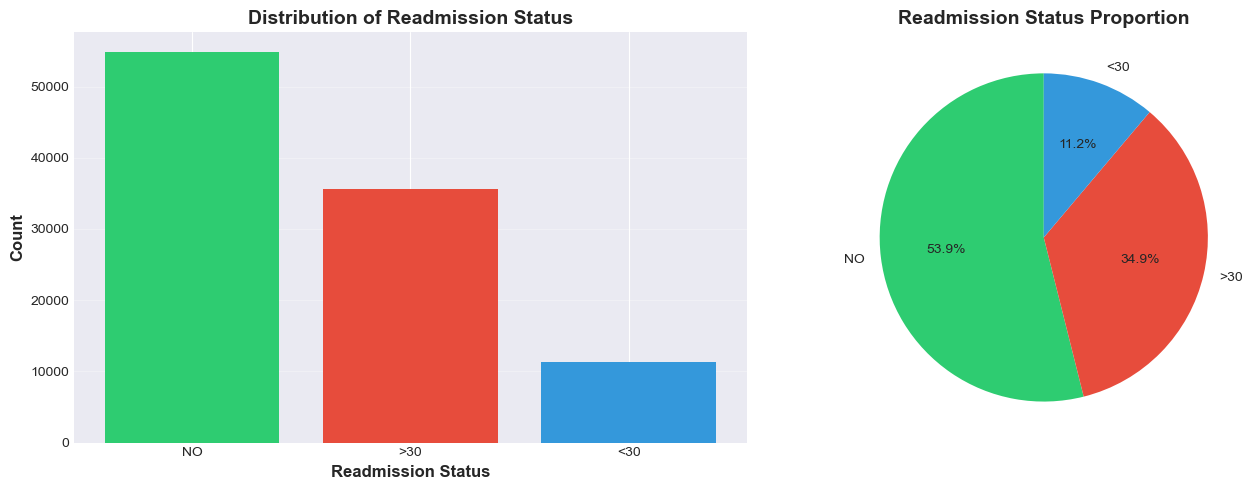


⚠️ CLASS IMBALANCE DETECTED - Will need to handle in modeling

NUMERICAL FEATURES ANALYSIS

Numerical features summary:
       time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
count         101766.00           101766.00       101766.00        101766.00   
mean               4.40               43.10            1.34            16.02   
std                2.99               19.67            1.71             8.13   
min                1.00                1.00            0.00             1.00   
25%                2.00               31.00            0.00            10.00   
50%                4.00               44.00            1.00            15.00   
75%                6.00               57.00            2.00            20.00   
max               14.00              132.00            6.00            81.00   

       number_outpatient  number_emergency  number_inpatient  number_diagnoses  
count          101766.00         101766.00         101766.00         101766.0

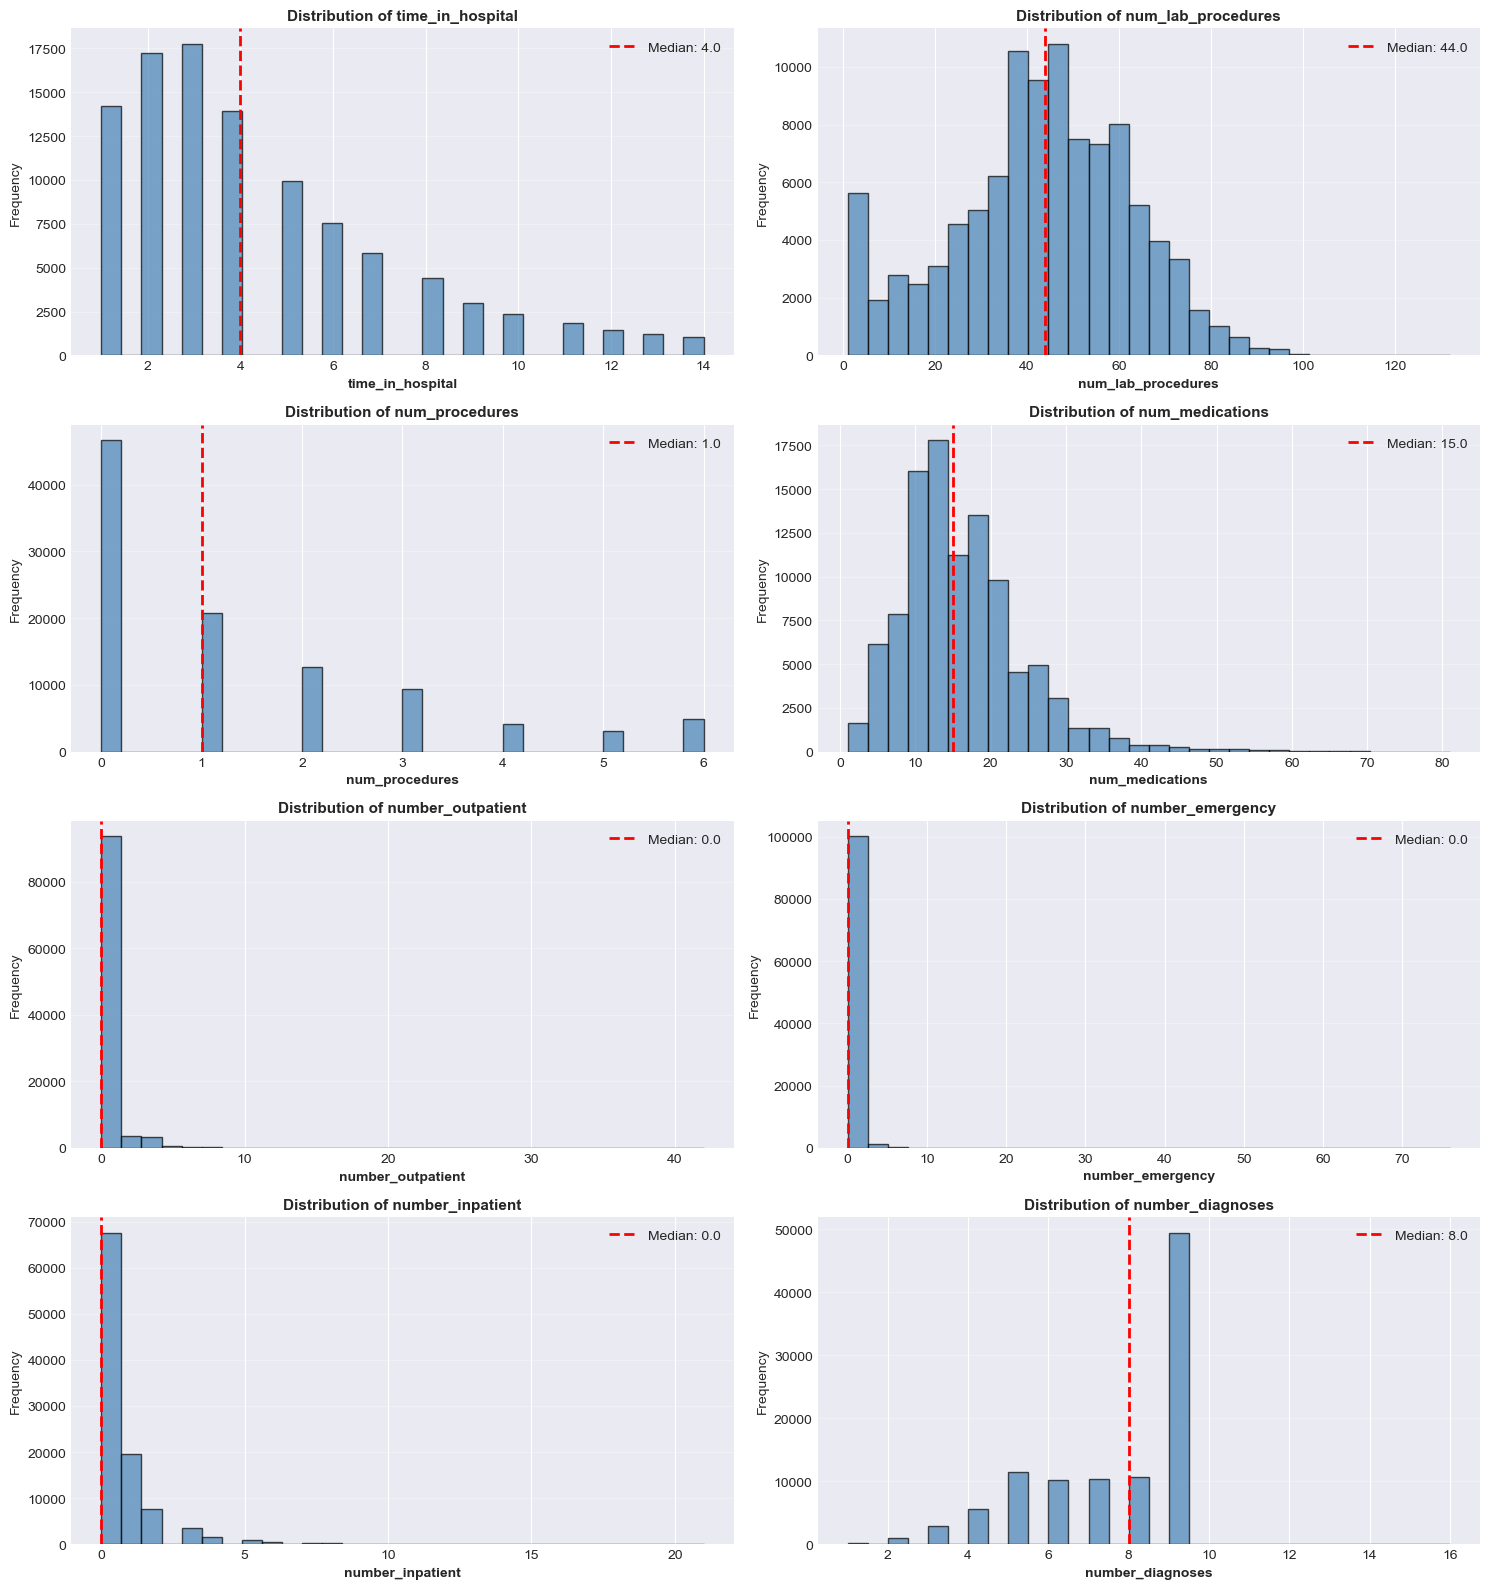


CATEGORICAL FEATURES ANALYSIS

Unique values in categorical features:
race: 6 unique values
gender: 3 unique values
age: 10 unique values
admission_type_id: 8 unique values
discharge_disposition_id: 26 unique values
admission_source_id: 17 unique values


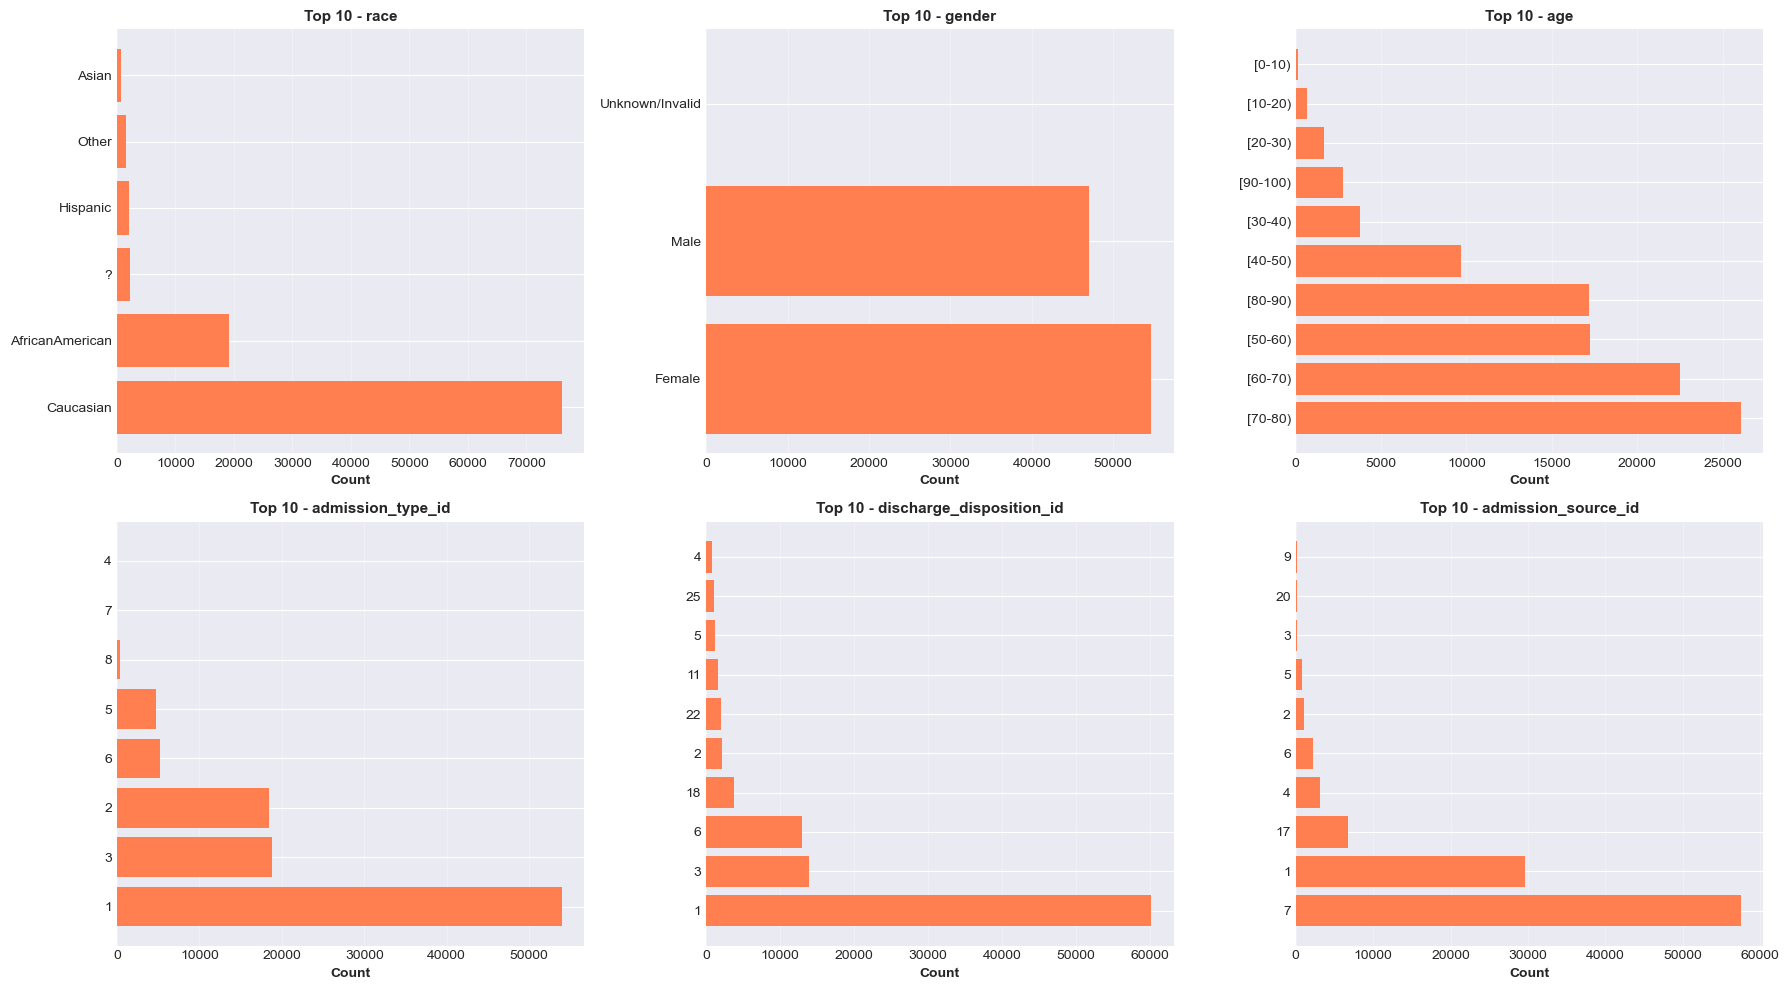


READMISSION ANALYSIS BY KEY FEATURES

Readmission by Age Group:
readmitted    <30    >30     NO
age                            
[0-10)       1.86  16.15  81.99
[10-20)      5.79  32.42  61.79
[20-30)     14.24  30.78  54.98
[30-40)     11.23  31.44  57.32
[40-50)     10.60  33.85  55.55
[50-60)      9.67  34.29  56.04
[60-70)     11.13  35.12  53.75
[70-80)     11.77  36.35  51.88
[80-90)     12.08  36.19  51.73
[90-100)    11.10  28.93  59.97


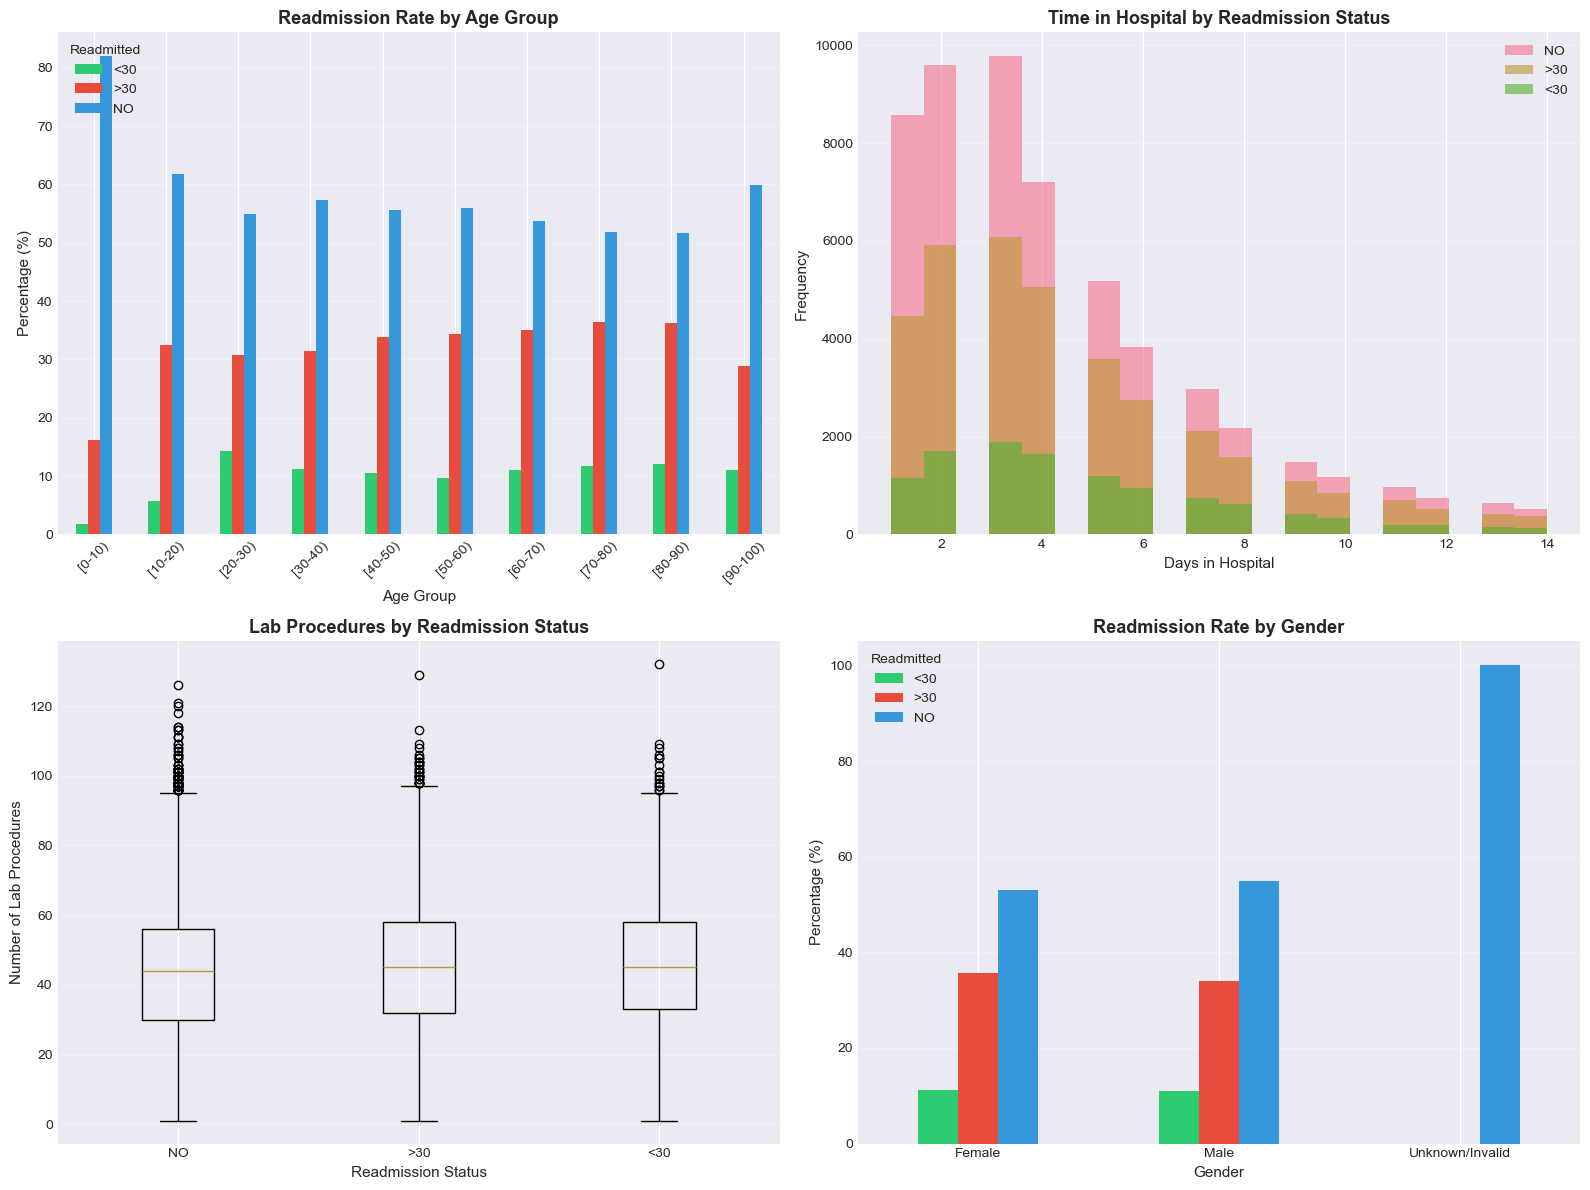


CORRELATION ANALYSIS


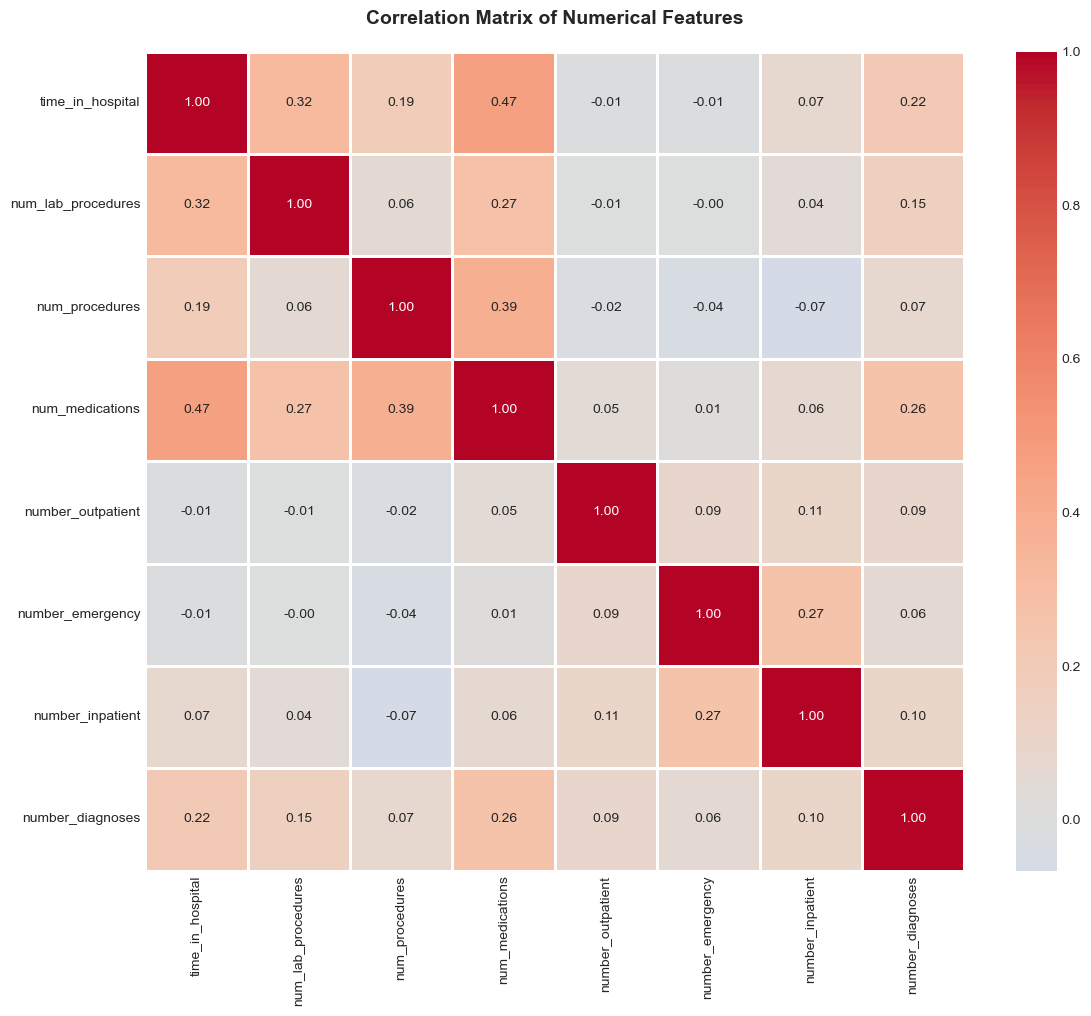


Top Correlated Feature Pairs:
num_medications     time_in_hospital      0.466135
                    num_procedures        0.385767
num_lab_procedures  time_in_hospital      0.318450
num_medications     num_lab_procedures    0.268161
number_inpatient    number_emergency      0.266559
number_diagnoses    num_medications       0.261526
                    time_in_hospital      0.220186
num_procedures      time_in_hospital      0.191472
number_diagnoses    num_lab_procedures    0.152773
number_inpatient    number_outpatient     0.107338
dtype: float64

KEY FINDINGS SUMMARY

✅ DATA QUALITY:
   - Dataset has 101,766 patient records with 50 features
   - Several columns have missing values ('?') - need handling
   - No true NULL values, but need to process '?' as missing

⚠️ CLASS IMBALANCE:
   - Significant imbalance in target variable
   - Will require techniques like SMOTE or class weighting

📊 KEY INSIGHTS:
   1. Elderly patients (70+) show different readmission patterns
   2. Time in h

In [15]:
# Hospital Readmission Prediction - Exploratory Data Analysis
# Author: HAMOUMA Sihem
# Date: [15/11/2025]

# ============================================================
# PART 1: INITIAL DATA LOADING AND OVERVIEW
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load data
print("Loading dataset...")
df = pd.read_csv('C:\\Users\\lenovo\\Desktop\\hospital-readmission-prediction\\data\\raw\\diabetic_data.csv')


print(f"\n{'='*60}")
print(f"DATASET OVERVIEW")
print(f"{'='*60}")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Display first few rows
print("\nFirst 5 rows:")
df.head()

# ============================================================
# PART 2: DATA TYPES AND MISSING VALUES
# ============================================================

print(f"\n{'='*60}")
print(f"DATA TYPES AND MISSING VALUES")
print(f"{'='*60}")

# Data types
print("\nData types:")
print(df.dtypes.value_counts())

# Missing values (represented as "?")
print("\nColumns with missing values ('?'):")
missing_cols = []
for col in df.columns:
    if df[col].dtype == 'object':
        missing_count = (df[col] == '?').sum()
        if missing_count > 0:
            missing_pct = (missing_count / len(df)) * 100
            missing_cols.append({
                'Column': col,
                'Missing Count': missing_count,
                'Missing %': missing_pct
            })

missing_df = pd.DataFrame(missing_cols).sort_values('Missing %', ascending=False)
print(missing_df.to_string(index=False))

# ============================================================
# PART 3: TARGET VARIABLE ANALYSIS
# ============================================================

print(f"\n{'='*60}")
print(f"TARGET VARIABLE ANALYSIS")
print(f"{'='*60}")

# Readmitted distribution
print("\nReadmitted distribution:")
readmit_counts = df['readmitted'].value_counts()
readmit_pcts = df['readmitted'].value_counts(normalize=True) * 100
readmit_summary = pd.DataFrame({
    'Count': readmit_counts,
    'Percentage': readmit_pcts.round(2)
})
print(readmit_summary)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
axes[0].bar(readmit_counts.index, readmit_counts.values, color=['#2ecc71', '#e74c3c', '#3498db'])
axes[0].set_xlabel('Readmission Status', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution of Readmission Status', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
colors = ['#2ecc71', '#e74c3c', '#3498db']
axes[1].pie(readmit_counts.values, labels=readmit_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Readmission Status Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('C:/Users/lenovo/Desktop/hospital-readmission-prediction/reports/figures/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n⚠️ CLASS IMBALANCE DETECTED - Will need to handle in modeling")

# ============================================================
# PART 4: NUMERICAL FEATURES ANALYSIS
# ============================================================

print(f"\n{'='*60}")
print(f"NUMERICAL FEATURES ANALYSIS")
print(f"{'='*60}")

# Select numerical columns
numerical_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                  'num_medications', 'number_outpatient', 'number_emergency',
                  'number_inpatient', 'number_diagnoses']

# Statistics
print("\nNumerical features summary:")
print(df[numerical_cols].describe().round(2))

# Distributions
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(col, fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add median line
    median_val = df[col].median()
    axes[idx].axvline(median_val, color='red', linestyle='--', linewidth=2, 
                      label=f'Median: {median_val:.1f}')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('C:/Users/lenovo/Desktop/hospital-readmission-prediction/reports/figures/numerical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# PART 5: CATEGORICAL FEATURES ANALYSIS
# ============================================================

print(f"\n{'='*60}")
print(f"CATEGORICAL FEATURES ANALYSIS")
print(f"{'='*60}")

# Key categorical features
categorical_cols = ['race', 'gender', 'age', 'admission_type_id', 
                   'discharge_disposition_id', 'admission_source_id']

print("\nUnique values in categorical features:")
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count} unique values")

# Visualize key categoricals
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols[:6]):
    top_categories = df[col].value_counts().head(10)
    axes[idx].barh(range(len(top_categories)), top_categories.values, color='coral')
    axes[idx].set_yticks(range(len(top_categories)))
    axes[idx].set_yticklabels(top_categories.index)
    axes[idx].set_xlabel('Count', fontsize=10, fontweight='bold')
    axes[idx].set_title(f'Top 10 - {col}', fontsize=11, fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('C:/Users/lenovo/Desktop/hospital-readmission-prediction/reports/figures/categorical_distributions.png', dpi=300, bbox_inches ='tight')
plt.show()

# ============================================================
# PART 6: READMISSION BY KEY FEATURES
# ============================================================

print(f"\n{'='*60}")
print(f"READMISSION ANALYSIS BY KEY FEATURES")
print(f"{'='*60}")

# Age groups analysis
print("\nReadmission by Age Group:")
age_readmit = pd.crosstab(df['age'], df['readmitted'], normalize='index') * 100
print(age_readmit.round(2))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Readmission by Age
age_readmit.plot(kind='bar', ax=axes[0, 0], color=['#2ecc71', '#e74c3c', '#3498db'])
axes[0, 0].set_title('Readmission Rate by Age Group', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Age Group', fontsize=11)
axes[0, 0].set_ylabel('Percentage (%)', fontsize=11)
axes[0, 0].legend(title='Readmitted', loc='upper left')
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Time in Hospital vs Readmission
for readmit_status in df['readmitted'].unique():
    subset = df[df['readmitted'] == readmit_status]['time_in_hospital']
    axes[0, 1].hist(subset, bins=20, alpha=0.6, label=readmit_status)
axes[0, 1].set_title('Time in Hospital by Readmission Status', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Days in Hospital', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Number of Lab Procedures
axes[1, 0].boxplot([df[df['readmitted']=='NO']['num_lab_procedures'],
                     df[df['readmitted']=='>30']['num_lab_procedures'],
                     df[df['readmitted']=='<30']['num_lab_procedures']],
                    labels=['NO', '>30', '<30'])
axes[1, 0].set_title('Lab Procedures by Readmission Status', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Readmission Status', fontsize=11)
axes[1, 0].set_ylabel('Number of Lab Procedures', fontsize=11)
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Gender distribution
gender_readmit = pd.crosstab(df['gender'], df['readmitted'], normalize='index') * 100
gender_readmit.plot(kind='bar', ax=axes[1, 1], color=['#2ecc71', '#e74c3c', '#3498db'])
axes[1, 1].set_title('Readmission Rate by Gender', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Gender', fontsize=11)
axes[1, 1].set_ylabel('Percentage (%)', fontsize=11)
axes[1, 1].legend(title='Readmitted')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('C:/Users/lenovo/Desktop/hospital-readmission-prediction/reports/figures/readmission_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# PART 7: CORRELATION ANALYSIS
# ============================================================

print(f"\n{'='*60}")
print(f"CORRELATION ANALYSIS")
print(f"{'='*60}")

# Correlation matrix for numerical features
corr_matrix = df[numerical_cols].corr()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('C:/Users/lenovo/Desktop/hospital-readmission-prediction/reports/figures/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop Correlated Feature Pairs:")
# Get upper triangle of correlation matrix
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
correlations = upper_triangle.unstack().dropna().sort_values(ascending=False)
print(correlations.head(10))

# ============================================================
# PART 8: KEY FINDINGS SUMMARY
# ============================================================
print(f"\n{'='*60}")
print(f"KEY FINDINGS SUMMARY")
print(f"{'='*60}")

print("""
✅ DATA QUALITY:
   - Dataset has 101,766 patient records with 50 features
   - Several columns have missing values ('?') - need handling
   - No true NULL values, but need to process '?' as missing

⚠️ CLASS IMBALANCE:
   - Significant imbalance in target variable
   - Will require techniques like SMOTE or class weighting

📊 KEY INSIGHTS:
   1. Elderly patients (70+) show different readmission patterns
   2. Time in hospital correlates with readmission risk
   3. Number of prior inpatient/emergency visits is important
   4. Lab procedures and medications count matter

🎯 NEXT STEPS:
   1. Handle missing values (weight, medical_specialty, etc.)
   2. Feature engineering (combine diagnosis codes, create risk scores)
   3. Address class imbalance in modeling
   4. Consider early readmission (<30 days) as high-priority class
""")

print("\n✓ Exploratory Data Analysis Complete!")
print("📁 All visualizations saved to: reports/figures/")